# Learning Entity Embeddings over RDBs

The notebook walks you through how to train entity embeddings using graph-centric techniques, i.e., GNNs. The dataset used is DonorsChoose, first released in KDD'14 competition. https://www.kaggle.com/c/kdd-cup-2014-predicting-excitement-at-donors-choose/data .

## Load data

In [1]:
import dbinfer_bench as dbb

dataset = dbb.load_rdb_data('donors')

The code below visualize the table schema.

In [2]:
from sqlalchemy import create_engine
from sqlalchemy_schemadisplay import create_schema_graph
# Use the sqlalchemy_metadata attribute to get metadata in sqlalchemy format.
sa_metadata = dataset.sqlalchemy_metadata
graph = create_schema_graph(engine=create_engine('sqlite://'),  # Use a temporary in-memory sqlite db.
                            metadata=sa_metadata,
                            show_datatypes=True,                # The image would show datatypes
                            show_indexes=True,                  # The image would show index names and unique constraints
                            rankdir='LR',                       # From left to right, instead of top to bottom
                            concentrate=False)                  # Don't try to join the relation lines together

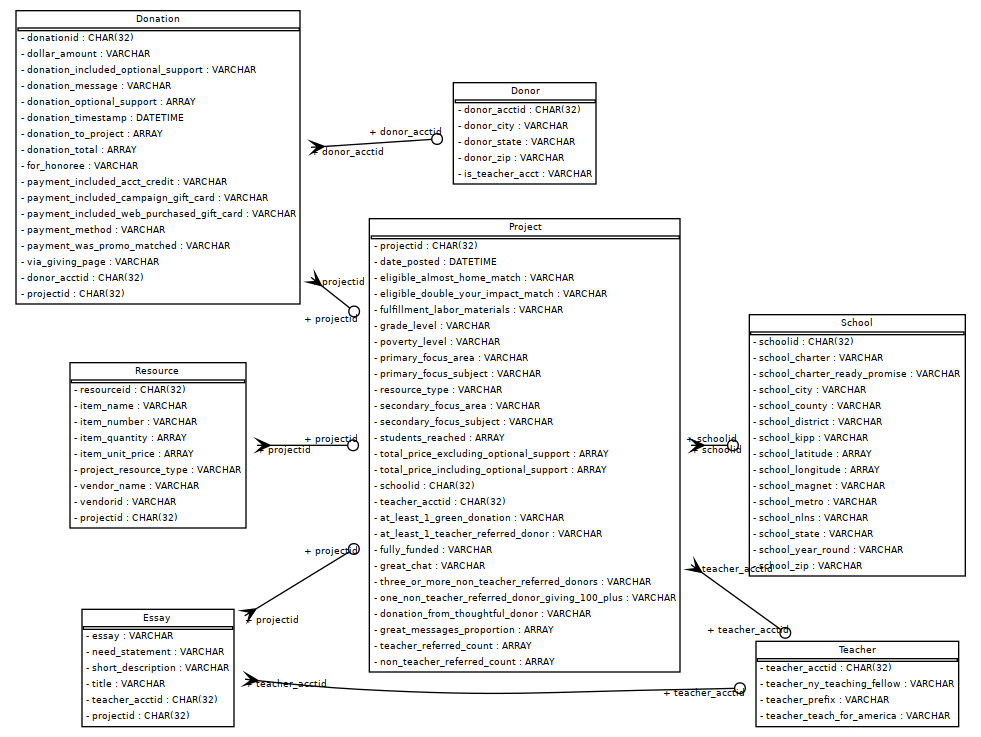

In [3]:
from IPython.display import Image, display

plt = Image(graph.create_png())
display(plt)

Printing the table contents shows its complex nature, i.e., columns of different modality.

In [4]:
import pandas as pd

donation_df = pd.DataFrame(dataset.tables['Donation'])
print(donation_df)

                               donationid                         projectid  \
0        431d720bc3dfd75ae445a5eaa0b0638d  ffffac55ee02a49d1abc87ba6fc61135   
1        fcfedba1c8a0ba77d280cace80a909f6  ffffac55ee02a49d1abc87ba6fc61135   
2        3fa95d29986aa6f401c6719ced3a3ce7  ffffac55ee02a49d1abc87ba6fc61135   
3        020ad6bd5e88a35741d23b5e08f8b8e8  ffffac55ee02a49d1abc87ba6fc61135   
4        4b44b03f304d6425ae94446686f93cd6  ffffac55ee02a49d1abc87ba6fc61135   
...                                   ...                               ...   
3097984  13496fce58def44b9a599cbcf47341a1  00002bff514104264a6b798356fdd893   
3097985  c73ae246117c943789016c981722a35c  00002bff514104264a6b798356fdd893   
3097986  6852f37d0f4cb3e3707ac57f07576a3b  00001ccc0e81598c4bd86bacb94d7acb   
3097987  014654dc6c8c42d9b95727364c680f64  00001ccc0e81598c4bd86bacb94d7acb   
3097988  1f22e76fa76c2c9e8d90818b7c275845  00001ccc0e81598c4bd86bacb94d7acb   

                             donor_acctid      dona

## Create a prediction task

The default task provided by the dataset is to predict whether a project is exiciting (likely to receive more donations). Here, we show how to create a different task that predicts which project a donor will likely contribute -- a typical recommendation setting.

In [5]:
task_df = donation_df.reindex(columns=['projectid', 'donor_acctid', 'donation_timestamp']).sort_values(by=['donation_timestamp'])
print(task_df)

                                projectid                      donor_acctid  \
145410   f401c1ec7aa97e7a100f01eff31b6076  40343e3336dfbd434fef6788f2b01141   
1615294  7acce7a28ef212fc578dc6de51e89f4c  9297792d7f9346b3517081e2f1a27d0e   
1193660  9dadca1ebe56a2cfeed4deefc4380fa5  6a0ed93f70c40e9e436dc505930c4267   
1763559  6e6e7b2ef5c53a9407e284f483484a38  9297792d7f9346b3517081e2f1a27d0e   
2650339  2503ca2bf78232e6396dcbd15449400a  9297792d7f9346b3517081e2f1a27d0e   
...                                   ...                               ...   
2737796  1de851135e28ac7c5223150e7b8dd96b  c306e5e459295d7d1c54052d4a96d130   
2737795  1de851135e28ac7c5223150e7b8dd96b  7f028d9e689b95809196a7cc36239133   
2737794  1de851135e28ac7c5223150e7b8dd96b  88303becda317627cbbe22bdb871c077   
1467875  86cecea3fca5ef5ac10c01c8f855b0cc  39d74dcd49d3d5cd4427fc446355f3fc   
1201793  9d021a8c7162f26cb5ca91b596360b50  a42183a5888f8572fbde875f90f967d5   

             donation_timestamp  
145410  2000-03-0

In [6]:
from tab2graph.task_construct_utils import generate_eval_negative_samples

# Downsample to make it faster for demo.
task_df = task_df.tail(n=100000)

num_rows = len(task_df)
num_train = int(num_rows * 0.8)
num_val = int(num_rows * 0.1)
num_test = num_rows - num_train - num_val

train_df = task_df.iloc[:num_train]
val_df = task_df.iloc[num_train:num_train+num_val]
test_df = task_df.iloc[num_train+num_val:]

val_df = generate_eval_negative_samples(val_df, task_df, 'projectid', 100)
test_df = generate_eval_negative_samples(test_df, task_df, 'projectid', 100)

print('#Train samples', len(train_df))
print('#Validation samples', len(val_df))
print('#Test samples', len(test_df))

#Train samples 80000
#Validation samples 915533
#Test samples 921599


In [7]:
import yaml

# Task metadata
task_meta_str = """
name: donation
columns:
    - name: projectid
      dtype: foreign_key
      link_to: Project.projectid
    - name: donor_acctid
      dtype: foreign_key
      link_to: Donor.donor_acctid
    - name: donation_timestamp
      dtype: datetime
time_column: donation_timestamp
evaluation_metric: mrr
target_column: projectid
target_table: Donation
task_type: retrieval
source: donation/{split}.pqt
format: parquet
"""
task_meta = mtbench.MTBTaskMeta.parse_obj(yaml.safe_load(task_meta_str))

# Save train/val/test samples to the dataset.
task = mtbench.MTBRDBTask(
    metadata=task_meta,
    train_set=train_df,
    validation_set=val_df,
    test_set=test_df)
dataset.tasks.append(task)

# Save to disk.
dataset.save('../datasets/donors_with_task')

## Running GNN pipeline

**Step.1 Featurization**

In [9]:
!python -m tab2graph.main preprocess ../datasets/donors_with_task transform ../datasets/donors_with_task-single

/ebs/miniconda3/envs/tab2graph-gpu/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libc10_hip.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
[I][2024-04-23 05:44:03,preprocess.py:46] No solution configuration file provided. Use default configuration.
[D][2024-04-23 05:44:03,preprocess.py:52] Config:
{"transforms": [{"name": "handle_dummy_table", "config": {}}, {"name": "key_mapping", "config": {}}, {"name": "column_transform_chain", "config": {"transforms": [{"name": "canonicalize_numeric"}, {"name": "canonicalize_datetime"}, {"name": "glove_text_embedding"}, {"name": "featurize_datetime", "config": {"methods": ["YEAR", "MONTH", "DAY", "DAYOFWEEK", "TIMESTAMP"]}}, {"name": "norm_numeric"}, {"name": "remap_category"}]}}, {"name": "filter_column", "config": {}}, {"name": "fill_timestamp", "config": {}}]}
[I][2024-04-23 05:44:03,preprocess.py:54] Loading data ..

**Step.2 Graph construction**

In [10]:
!python -m tab2graph.main construct-graph ../datasets/donors_with_task-single r2ne ../datasets/donors_with_task-r2ne

/ebs/miniconda3/envs/tab2graph-gpu/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libc10_hip.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
[I][2024-04-23 05:52:12,construct_graph.py:40] Loading data.
[I][2024-04-23 05:52:15,construct_graph.py:44] No configuration file provided. Use default configuration.
[D][2024-04-23 05:52:15,construct_graph.py:49] {"relation_table_as_edge": true}
[I][2024-04-23 05:52:15,construct_graph.py:51] Creating graph construction class.
[I][2024-04-23 05:52:15,er_graph_construction.py:87] Table domain: {'Donation': 'edge', 'Donor': 'node', 'Project': 'node', 'Essay': 'edge', 'Teacher': 'node', 'School': 'node', 'Resource': 'node'}
[I][2024-04-23 05:52:15,er_graph_construction.py:96] Building nodes...
[I][2024-04-23 05:52:15,er_graph_construction.py:102] Add node Donor with 1282092 nodes.
[I][2024-04-23 05:52:15,er_graph_constructi

**Step 3. Training GNNs**

We then use a R-SAGE model to learn an embedding vector for each donor. First, define the model configuration file. The `embed_ntypes` field should include the type of nodes to learn embeddings for.

In [14]:
model_config_str = """
lr : 0.001                 # Learning rate
batch_size : 512           # Batch size
eval_batch_size : 512      # Evaluation batch size
fanouts : [20, 20]         # Sampling fanouts
hid_size : 128             # Hidden size
feat_encode_size : 8       # Input feature embedding size
dropout : 0.1              # Dropout
predictor:
  num_layers: 5            # Number of predictor head layers
  hid_size: 128            # Predictor head hidden size
  dropout: 0.1             # Predictor head dropout
patience: 30               # Early stop patience
eval_trials: 3             # Number of evaluation trials to reduce variance
embed_ntypes:              # Table/Node types to learn embeddings
  - Donor
"""
with open('donor-rsage.yaml', 'w') as f:
    f.write(model_config_str)

Launch training using one command.

In [13]:
!python -m tab2graph.main fit-gml ../datasets/donors_with_task-r2ne donation sage -c donor-rsage.yaml -p workspace --disable-wandb

/ebs/miniconda3/envs/tab2graph-gpu/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libc10_hip.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
[I][2024-04-23 06:00:02,fit_gml.py:64] Load solution configuration file: donor-rsage.yaml.
[D][2024-04-23 06:00:02,fit_gml.py:67] Solution config:
{"lr": 0.001, "batch_size": 512, "eval_batch_size": 512, "feat_encode_size": 8, "fanouts": [20, 20], "eval_fanouts": null, "negative_sampling_ratio": 5, "patience": 15, "epochs": 200, "embed_ntypes": ["Donor"], "enable_temporal_sampling": true, "time_budget": 3600, "predictor": {"num_layers": 5, "hid_size": 128, "dropout": 0.1}, "use_multiprocessing": true, "eval_trials": 5, "hid_size": 128, "dropout": 0.1, "conv": {"has_bias": true}}
[I][2024-04-23 06:00:02,fit_gml.py:69] Loading data ...
Start to preprocess the on-disk dataset.
Finish preprocessing the on-disk dataset.
[D][2

**Step 4. Extract learned node embeddings**

In [1]:
!python -m tab2graph.main get-node-embed sage workspace/sage-run-0/ donor-embed.pt

/ebs/miniconda3/envs/tab2graph-gpu/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libc10_hip.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")
[I][2024-04-23 10:46:39,get_node_embed.py:47] Load solution configuration file: workspace/sage-run-0/solution_config.yaml.
[D][2024-04-23 10:46:39,get_node_embed.py:49] Solution config:
{"lr": 0.001, "batch_size": 512, "eval_batch_size": 512, "feat_encode_size": 8, "fanouts": [20, 20], "eval_fanouts": null, "negative_sampling_ratio": 5, "patience": 30, "epochs": 200, "embed_ntypes": ["Donor"], "enable_temporal_sampling": true, "time_budget": 0.0, "predictor": {"num_layers": 5, "hid_size": 128, "dropout": 0.1}, "use_multiprocessing": true, "eval_trials": 3, "hid_size": 128, "dropout": 0.1, "conv": {"has_bias": true}}
[I][2024-04-23 10:46:39,get_node_embed.py:53] Creating solution ...
[D][2024-04-23 10:46:39,base_gml_solut

In [3]:
import torch

donor_embed = torch.load('donor-embed.pt')
print(donor_embed)
print(donor_embed['Donor'].shape)

{'Donor': Parameter containing:
tensor([[ 1.9062e-02,  1.8291e-02, -1.9741e-02,  ..., -1.8509e-02,
         -1.7553e-02, -1.9516e-02],
        [ 8.1820e-04, -3.9918e-04,  7.2363e-04,  ..., -2.0116e-03,
          1.3855e-03,  1.5692e-03],
        [ 1.6691e-03, -9.1050e-04, -1.7459e-03,  ..., -3.6325e-03,
         -3.3242e-03, -2.1606e-03],
        ...,
        [ 8.6837e-03,  7.6912e-03, -6.8796e-03,  ..., -9.2872e-03,
         -7.8705e-03, -9.6772e-03],
        [-1.5152e-03, -3.9333e-04, -1.2130e-03,  ..., -1.4830e-03,
         -1.8576e-03, -7.9228e-04],
        [-7.4915e-04, -1.9223e-03, -2.4503e-05,  ..., -1.4018e-04,
          1.1540e-03,  8.3381e-04]], requires_grad=True)}
torch.Size([1282092, 8])
